In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns

### 1. Input data 

In [2]:
bd_df = gpd.read_file('input_data/grenoble_building_dataset_annual_conso.gpkg')
mesh_df = pd.read_csv('input_data/mesh_agg_all.csv')
weighted_df = pd.read_csv('input_data/Weighted_Coefficient.csv')

In [3]:
bd_df = pd.DataFrame(bd_df)
bd_df

,batiment_construction_id,batiment_groupe_id,code_commune_insee,BDNB_hauteur,BDNB_altitude_sol,BDNB_fictive_geom_cstr,ONB_id,ONB_typobati,ONB_consoelec,ONB_parcelle_id,...,CARREAU_part_menages_monoparentaux,CARREAU_part_logement_collectif,CARREAU_part_logement_maison,CARREAU_part_logements_sociaux,CARREAU_age_moyen_occupants,CARREAU_revenu_bat,pred_residential_mwh,pred_non_residential_mwh,pred_total_mwh,geometry
0,bdnb-bc-GX51-FD2U-XY2R,bdnb-bg-KHK4-PQZ5-FR3L,38185,6.1,214.0,False,67332f71-553e-4405-8fca-2e272504c23d,habitation,NaN,38185000IS0009,...,0.067633,0.971014,0.028986,0.111111,33.585106,7245.011431,0.503110,0.000000,0.503110,"MULTIPOLYGON (((912498.6 6457540.8, 912498.6 6..."
1,bdnb-bc-SE6P-MXT5-JWWV,bdnb-bg-MELJ-WRU7-KRMG,38185,2.6,213.7,False,95f1abf5-5939-48d1-bb0d-3424a4fb86f5,habitation,NaN,38185000IP0269,...,0.127596,0.925816,0.074184,0.195846,36.987776,15221.105961,1.511264,0.000000,1.511264,"MULTIPOLYGON (((912600.4 6457772.2, 912604.7 6..."
2,bdnb-bc-HCP8-G6A5-YNVB,bdnb-bg-H2ZZ-3GBX-R5YC,38185,2.2,214.0,False,395ee37a-c57a-4e42-b357-abbcb43d2343,habitation,NaN,38185000IO0012,...,0.127596,0.925816,0.074184,0.195846,36.987776,30442.211913,2.661698,0.000000,2.661698,"MULTIPOLYGON (((912489.5 6457895.6, 912492.3 6..."
3,bdnb-bc-UWNC-YMMH-P8FN,bdnb-bg-MNQK-ELQV-56SX,38185,10.7,213.7,False,da055acf-993d-4ff1-9b92-4ddb92ac120e,habitation et activite,NaN,38185000HY0055,...,0.085973,0.988688,0.011312,0.047511,38.876756,8937.324820,0.591369,0.416212,1.007581,"MULTIPOLYGON (((913354.2 6457457.3, 913353.8 6..."
4,bdnb-bc-5N7F-E3H4-1M3S,bdnb-bg-MX83-N55C-EP1E,38185,15.4,213.0,False,0ba3a88f-0a76-4a1a-9e0e-8d0676fc33c7,habitation,NaN,38185000HZ0025,...,0.102757,0.987469,0.012531,0.230576,40.721327,8373.425073,0.653499,0.000000,0.653499,"MULTIPOLYGON (((913056.6 6457753.9, 913056.6 6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15868,bdnb-bc-89Z5-NYW7-1SS5,bdnb-bg-ZV3H-EDUC-H6N3,38185,12.3,220.2,False,5b6938eb-433a-415a-b138-c31509e38af7,activite,NaN,38185000EV0051,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,93.914478,93.914478,"MULTIPOLYGON (((915011.5 6454777.9, 915012.8 6..."
15869,bdnb-bc-PKC2-CR64-HSUY,bdnb-bg-ZV3H-EDUC-H6N3,38185,6.4,220.7,False,848453ab-3bd4-4aaa-9568-6c9a9a37d70b,activite,NaN,38185000EV0051,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,7.631071,7.631071,"MULTIPOLYGON (((914939 6454811.4, 914940.1 645..."
15870,bdnb-bc-SXBF-SUGC-LGWT,bdnb-bg-ZV3H-EDUC-H6N3,38185,10.5,220.7,False,a9bad93b-59f8-4db6-96b1-6a23fe3e8efa,activite,NaN,38185000EV0051,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,17.649116,17.649116,"MULTIPOLYGON (((914972.5 6454753.1, 914968.3 6..."
15871,bdnb-bc-UXJG-V38J-59U7,bdnb-bg-ZV3H-EDUC-H6N3,38185,11.2,220.7,False,5c6406d0-90f9-4acf-8d6d-3736119fe91c,activite,NaN,38185000EV0051,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,213.621366,213.621366,"MULTIPOLYGON (((914978 6454759.3, 914972.5 645..."


In [4]:
items1 = ['batiment_construction_id','HTA_maille','pred_residential_mwh', 'CARREAU_nb_individus', 'CARREAU_surface_par_personne','surface_residentiel_collectif_electricite', 'surface_residentiel_individuel_electricite', 'CARREAU_revenu_par_habitant', 'CARREAU_nb_logements_sociaux',
         'FUS_annee_construction', 'CARREAU_age_moyen_occupants', 'surface_residentiel_collectif_non_electricite', 'surface_residentiel_individuel_non_electricite', 'CARREAU_nb_menages', 'CARREAU_nb_menages_maisons', 
         'surface_tertiaire_electricite', 'surface_tertiaire_non_electricite', 'surface_dependance', 'surface_secondaire', 'CARREAU_nb_individus_0_3', 'CARREAU_nb_individus_4_5', 'CARREAU_nb_individus_6_10', 'CARREAU_nb_individus_11_17', 'CARREAU_nb_individus_18_24', 
         'CARREAU_nb_individus_25_39', 'CARREAU_nb_individus_40_54', 'CARREAU_nb_individus_55_64', 'CARREAU_nb_individus_65_79', 'CARREAU_nb_individus_80_plus', 'CARREAU_nb_individus_age_inconnu', 'CARREAU_revenu_bat', 'FUS_nb_log', 'CARREAU_nb_menages_pauvres', 
         'CARREAU_nb_menages_1_individu', 'CARREAU_nb_menages_5_indiv_et_plus', 'CARREAU_nb_menages_proprietaires', 'CARREAU_nb_menages_monoparentaux', 'CARREAU_surface_logements_carreau', 'CARREAU_nb_menages_logements_collectifs', 'BDNB_hauteur', 'FUS_usage_principal', 'geometry']

items2 = ['HTA_maille','pred_residential_mwh', 'CARREAU_nb_individus', 'CARREAU_surface_par_personne','surface_residentiel_collectif_electricite', 'surface_residentiel_individuel_electricite', 'CARREAU_revenu_par_habitant', 'CARREAU_nb_logements_sociaux',
         'FUS_annee_construction', 'CARREAU_age_moyen_occupants', 'surface_residentiel_collectif_non_electricite', 'surface_residentiel_individuel_non_electricite', 'CARREAU_nb_menages', 'CARREAU_nb_menages_maisons', 
         'surface_tertiaire_electricite', 'surface_tertiaire_non_electricite', 'surface_dependance', 'surface_secondaire', 'CARREAU_nb_individus_0_3', 'CARREAU_nb_individus_4_5', 'CARREAU_nb_individus_6_10', 'CARREAU_nb_individus_11_17', 'CARREAU_nb_individus_18_24', 
         'CARREAU_nb_individus_25_39', 'CARREAU_nb_individus_40_54', 'CARREAU_nb_individus_55_64', 'CARREAU_nb_individus_65_79', 'CARREAU_nb_individus_80_plus', 'CARREAU_nb_individus_age_inconnu', 'CARREAU_revenu_bat', 'FUS_nb_log', 'CARREAU_nb_menages_pauvres', 
         'CARREAU_nb_menages_1_individu', 'CARREAU_nb_menages_5_indiv_et_plus', 'CARREAU_nb_menages_proprietaires', 'CARREAU_nb_menages_monoparentaux', 'CARREAU_surface_logements_carreau', 'CARREAU_nb_menages_logements_collectifs', 'BDNB_hauteur']

In [5]:
# missing_cols = [col for col in items1 if col not in bd_df.columns]
# missing_cols

In [6]:
surface_residentiel_collectif_electricite = bd_df.loc[
    (bd_df['FUS_usage_principal'] == 'Résidentiel collectif') &
    (bd_df['FUS_energie_chauffage'] == 'electricite'),['batiment_construction_id','HTA_maille','FUS_surface_résidentielle']].fillna(0)

surface_residentiel_individuel_electricite = bd_df.loc[
    (bd_df['FUS_usage_principal'] == 'Résidentiel individuel') &
    (bd_df['FUS_energie_chauffage'] == 'electricite'),['batiment_construction_id','HTA_maille','FUS_surface_résidentielle']].fillna(0)

surface_residentiel_collectif_non_electricite = bd_df.loc[
    (bd_df['FUS_usage_principal'] == 'Résidentiel collectif') &
    (bd_df['FUS_energie_chauffage'] == 'non_electricite'),['batiment_construction_id','HTA_maille','FUS_surface_résidentielle']].fillna(0)

surface_residentiel_individuel_non_electricite = bd_df.loc[
    (bd_df['FUS_usage_principal'] == 'Résidentiel individuel') &
    (bd_df['FUS_energie_chauffage'] == 'non_electricite'),['batiment_construction_id','HTA_maille','FUS_surface_résidentielle']].fillna(0)

surface_tertiaire_electricite = bd_df.loc[
    (bd_df['FUS_usage_principal'] == 'Tertiaire') &
    (bd_df['FUS_energie_chauffage'] == 'electricite'),['batiment_construction_id','HTA_maille','FUS_surface_résidentielle']].fillna(0)

surface_tertiaire_non_electricite = bd_df.loc[
    (bd_df['FUS_usage_principal'] == 'Tertiaire') &
    (bd_df['FUS_energie_chauffage'] == 'non_electricite'),['batiment_construction_id','HTA_maille','FUS_surface_résidentielle']].fillna(0)

surface_dependance = bd_df.loc[
    (bd_df['FUS_usage_principal'] == 'Dépendance'),['batiment_construction_id','HTA_maille','FUS_surface_résidentielle']].fillna(0)

surface_secondaire = bd_df.loc[
    (bd_df['FUS_usage_principal'] == 'Secondaire'),['batiment_construction_id','HTA_maille','FUS_surface_résidentielle']].fillna(0)

In [7]:
valid_cols = [col for col in items1 if col in bd_df.columns]
bd_df_filtered = bd_df[valid_cols].dropna()

In [8]:
bd_df_filtered1 = bd_df_filtered.copy()

bd_df_filtered1 = bd_df_filtered1.merge(
    surface_residentiel_collectif_electricite,
    on=['batiment_construction_id', 'HTA_maille'],
    how='left').rename(columns={'FUS_surface_résidentielle': 'surface_residentiel_collectif_electricite'})

bd_df_filtered1 = bd_df_filtered1.merge(
    surface_residentiel_individuel_electricite,
    on=['batiment_construction_id', 'HTA_maille'],
    how='left').rename(columns={'FUS_surface_résidentielle': 'surface_residentiel_individuel_electricite'})

bd_df_filtered1 = bd_df_filtered1.merge(
    surface_residentiel_collectif_non_electricite,
    on=['batiment_construction_id', 'HTA_maille'],
    how='left').rename(columns={'FUS_surface_résidentielle': 'surface_residentiel_collectif_non_electricite'})

bd_df_filtered1 = bd_df_filtered1.merge(
    surface_residentiel_individuel_non_electricite,
    on=['batiment_construction_id', 'HTA_maille'],
    how='left').rename(columns={'FUS_surface_résidentielle': 'surface_residentiel_individuel_non_electricite'})


bd_df_filtered1 = bd_df_filtered1.merge(
    surface_tertiaire_electricite,
    on=['batiment_construction_id', 'HTA_maille'],
    how='left').rename(columns={'FUS_surface_résidentielle': 'surface_tertiaire_electricite'})

bd_df_filtered1 = bd_df_filtered1.merge(
    surface_tertiaire_non_electricite,
    on=['batiment_construction_id', 'HTA_maille'],
    how='left').rename(columns={'FUS_surface_résidentielle': 'surface_tertiaire_non_electricite'})

bd_df_filtered1 = bd_df_filtered1.merge(
    surface_dependance,
    on=['batiment_construction_id', 'HTA_maille'],
    how='left').rename(columns={'FUS_surface_résidentielle': 'surface_dependance'})

bd_df_filtered1 = bd_df_filtered1.merge(
    surface_secondaire,
    on=['batiment_construction_id', 'HTA_maille'],
    how='left').rename(columns={'FUS_surface_résidentielle': 'surface_secondaire'})

In [9]:
bd_df_filtered1 = bd_df_filtered1.filter(items1).sort_values('HTA_maille').fillna(0)

In [10]:
bd_df_filtered1['residential_total_surface'] = (
                                            bd_df_filtered1['surface_residentiel_individuel_electricite'] +
                                            bd_df_filtered1['surface_residentiel_individuel_non_electricite'] +
                                            bd_df_filtered1['surface_residentiel_collectif_electricite'] +
                                            bd_df_filtered1['surface_residentiel_collectif_non_electricite'])

bd_df_filtered1['total_surface_feature'] = (bd_df_filtered1['surface_tertiaire_electricite'] +
                                            bd_df_filtered1['surface_tertiaire_non_electricite'] +
                                            bd_df_filtered1['surface_residentiel_collectif_electricite'] +
                                            bd_df_filtered1['surface_residentiel_collectif_non_electricite'] +
                                            bd_df_filtered1['surface_residentiel_individuel_electricite'] +
                                            bd_df_filtered1['surface_residentiel_individuel_non_electricite'] +
                                            bd_df_filtered1['surface_dependance'] +
                                            bd_df_filtered1['surface_secondaire'])

In [11]:
items1 = ['CARREAU_nb_individus_0_3', 'CARREAU_nb_individus_4_5', 'CARREAU_nb_individus_6_10', 'CARREAU_nb_individus_11_17', 'CARREAU_nb_individus_18_24', 
        'CARREAU_nb_individus_25_39', 'CARREAU_nb_individus_40_54', 'CARREAU_nb_individus_55_64','CARREAU_nb_individus_65_79', 'CARREAU_nb_individus_80_plus']

items2 = ['CARREAU_nb_menages_pauvres','CARREAU_nb_menages_1_individu','CARREAU_nb_menages_5_indiv_et_plus','CARREAU_nb_menages_proprietaires',
        'CARREAU_nb_menages_monoparentaux','CARREAU_nb_menages_logements_collectifs','CARREAU_nb_logements_sociaux']

items3 = ['CARREAU_surface_logements_carreau','CARREAU_nb_individus_age_inconnu', 'FUS_annee_construction','CARREAU_surface_par_personne', 'CARREAU_age_moyen_occupants', 'CARREAU_revenu_par_habitant']

items4 = ['surface_tertiaire_electricite', 'surface_tertiaire_non_electricite', 'surface_residentiel_collectif_electricite', 'surface_residentiel_collectif_non_electricite',
        'surface_residentiel_individuel_electricite', 'surface_residentiel_individuel_non_electricite', 'surface_dependance', 'surface_secondaire', 'CARREAU_nb_menages_maisons', 'CARREAU_nb_menages', 'CARREAU_nb_individus']

In [12]:
total = len(items1) + len(items2) + len(items3) + len(items4)
total

34

In [13]:
bd_df_filtered1['conso_par_persone_mwh'] = bd_df_filtered1['pred_residential_mwh'] / bd_df_filtered1['CARREAU_nb_individus']
bd_df_filtered1['CARREAU_revenu_bat'] = bd_df_filtered1['CARREAU_revenu_bat'] / bd_df_filtered1['residential_total_surface']

bd_df_filtered1[items1] = bd_df_filtered1[items1].div(bd_df_filtered1['CARREAU_nb_individus'], axis=0)
bd_df_filtered1[items2] = bd_df_filtered1[items2].div(bd_df_filtered1['CARREAU_nb_menages'], axis=0)
bd_df_filtered1[items3] = bd_df_filtered1[items3].div(bd_df_filtered1['residential_total_surface'], axis=0)
bd_df_filtered1[items4] = bd_df_filtered1[items4].div(bd_df_filtered1['total_surface_feature'], axis=0)

In [14]:
bd_df_filtered1 = bd_df_filtered1.replace([np.inf], np.nan).fillna(0)

### 2. Normalized building dataset

In [15]:
bd_df_filtered1

,batiment_construction_id,HTA_maille,pred_residential_mwh,CARREAU_nb_individus,CARREAU_surface_par_personne,surface_residentiel_collectif_electricite,surface_residentiel_individuel_electricite,CARREAU_revenu_par_habitant,CARREAU_nb_logements_sociaux,FUS_annee_construction,...,CARREAU_nb_menages_proprietaires,CARREAU_nb_menages_monoparentaux,CARREAU_surface_logements_carreau,CARREAU_nb_menages_logements_collectifs,BDNB_hauteur,FUS_usage_principal,geometry,residential_total_surface,total_surface_feature,conso_par_persone_mwh
524,bdnb-bc-DWC7-AZG6-MPMS,F01,68.204508,0.013234,0.029897,1.0,0.0,9.942841,0.107527,0.787324,...,0.470430,0.112903,0.443768,0.981183,13.3,Résidentiel collectif,"MULTIPOLYGON (((912641.3 6458196.2, 912638.9 6...",2527.55,2527.5500,2.039086
1214,bdnb-bc-WFT8-9SYZ-23F4,F01,3.644187,0.009443,0.723053,1.0,0.0,182.795731,0.061972,12.972825,...,0.385915,0.050704,0.348841,0.994366,10.3,Résidentiel collectif,"MULTIPOLYGON (((913316.4 6458137.9, 913310.4 6...",146.46,146.4600,2.634940
1211,bdnb-bc-RHQP-FZ4B-2C4K,F01,20.099349,0.009443,0.089079,0.0,0.0,22.520220,0.061972,1.631043,...,0.385915,0.050704,0.348841,0.994366,11.6,Résidentiel collectif,"MULTIPOLYGON (((913328.8 6458158.6, 913338 645...",1188.81,1188.8100,1.790436
633,bdnb-bc-NBLV-U77H-59RM,F01,10.301721,0.013234,0.146215,0.0,0.0,48.627208,0.107527,3.869894,...,0.470430,0.112903,0.443768,0.981183,11.7,Résidentiel collectif,"MULTIPOLYGON (((912628.6 6458240, 912628.6 645...",516.81,516.8100,1.506264
634,bdnb-bc-ZWRY-3766-LZB7,F01,21.385662,0.013234,0.070617,0.0,0.0,23.485405,0.107527,1.869037,...,0.470430,0.112903,0.443768,0.981183,4.4,Résidentiel collectif,"MULTIPOLYGON (((912654.6 6458240, 912654.7 645...",1070.07,1070.0700,1.510194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,bdnb-bc-B8D5-B9KA-1P51,F39,13.331678,0.000424,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.111111,0.166667,0.000000,0.888889,5.0,Tertiaire,"MULTIPOLYGON (((911664 6460047.5, 911676.8 646...",0.00,1480.4050,21.255643
331,bdnb-bc-ZBZA-4WGD-XX86,F39,78.143166,0.004658,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.674699,0.060241,0.000000,1.000000,10.8,Tertiaire,"MULTIPOLYGON (((912447.8 6459743.2, 912465.2 6...",0.00,7186.3800,2.334623
330,bdnb-bc-XLB9-L62U-814D,F39,0.277726,0.004658,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.674699,0.060241,0.000000,1.000000,3.3,Tertiaire,"MULTIPOLYGON (((912565.3 6459640.8, 912561.9 6...",0.00,20.0275,2.977327
328,bdnb-bc-PXHF-SLDB-Q255,F39,1.787368,0.004658,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.674699,0.060241,0.000000,1.000000,2.8,Tertiaire,"MULTIPOLYGON (((912533.6 6459655.2, 912537 645...",0.00,129.9700,2.952615


In [16]:
### 24 feeder pair candidates
# col1 = ['F07_F27','F22']
col1 = ['F20_F22','F07_F27']
# col1 = ['F07', 'F22']
# col1 = ['F20', 'F27']
# col1 = ['F10_F25', 'F15_F16']
# col1 = ['F15_F20', 'F07_F27']
# col1 = ['F20', 'F07_F27']
# col1 = ['F07_F31', 'F22']
# col1 = ['F22_F23', 'F07_F31']
# col1 = ['F20_F22', 'F07']
# col1 = ['F15_F18', 'F10_F13']
# col1 = ['F27_F32', 'F20']
# col1 = ['F20', 'F07']
# col1 = ['F27_F32', 'F15_F20']
# col1 = ['F15_F16', 'F07_F08']
# col1 = ['F08_F31', 'F15_F16']
# col1 = ['F27_F32', 'F20_F22']
# col1 = ['F23', 'F07']
# col1 = ['F15_F18', 'F07_F08']
# col1 = ['F07_F08', 'F23']
# col1 = ['F18', 'F07_F08']
# col1 = ['F08_F31', 'F23']
# col1 = ['F07_F08', 'F20']
# col1 = ['F18', 'F08']

## List of Feeder ID covered by circle
# col1 = ['F01', 'F10', 'F15', 'F18', 'F20', 'F22', 'F23']
# col1 = ['F01', 'F10', 'F12', 'F15', 'F16', 'F17', 'F18', 'F20_F22', 'F23', 'F25', 'F28']

cols_split = [set(c.split('_')) for c in col1]

def get_combined_feeder(df, feeder_group, label):
    temp = df[df['HTA_maille'].isin(feeder_group)].copy()
    temp['pair_label'] = label
    return temp

combined_df = pd.concat([
    get_combined_feeder(bd_df_filtered1 , group, label)
    for group, label in zip(cols_split, col1)
], ignore_index=True)

### 3. Building dataset cosisting of the selected feeder pairs

In [17]:
combined_df

,batiment_construction_id,HTA_maille,pred_residential_mwh,CARREAU_nb_individus,CARREAU_surface_par_personne,surface_residentiel_collectif_electricite,surface_residentiel_individuel_electricite,CARREAU_revenu_par_habitant,CARREAU_nb_logements_sociaux,FUS_annee_construction,...,CARREAU_nb_menages_monoparentaux,CARREAU_surface_logements_carreau,CARREAU_nb_menages_logements_collectifs,BDNB_hauteur,FUS_usage_principal,geometry,residential_total_surface,total_surface_feature,conso_par_persone_mwh,pair_label
0,bdnb-bc-F75J-5B18-MZ7J,F20,3.699382,0.007412,0.457384,0.0,0.0,77.449989,0.107527,6.675029,...,0.089606,0.267210,0.985663,23.5,Résidentiel collectif,"MULTIPOLYGON (((914139.3 6457203.4, 914138.9 6...",294.980,294.9800,1.692038,F20_F22
1,bdnb-bc-9PWE-SBCK-MAU3,F20,60.672855,0.008595,0.026266,0.0,0.0,6.257099,0.030418,0.445212,...,0.087452,0.359122,0.958175,31.9,Résidentiel collectif,"MULTIPOLYGON (((913902.6 6457068.7, 913903.9 6...",4429.350,4429.3500,1.593617,F20_F22
2,bdnb-bc-F717-CGB2-NWDJ,F20,26.363290,0.012692,0.071944,1.0,0.0,23.289984,0.096154,1.763148,...,0.091346,0.497555,0.992788,20.7,Résidentiel collectif,"MULTIPOLYGON (((914144.6 6457263.2, 914147.1 6...",1095.200,1095.2000,1.896669,F20_F22
3,bdnb-bc-H75L-MJE1-JC77,F20,49.045577,0.012692,0.027263,0.0,0.0,8.825850,0.096154,0.681302,...,0.091346,0.497555,0.992788,28.5,Résidentiel collectif,"MULTIPOLYGON (((914148.7 6457194, 914141.7 645...",2890.055,2890.0550,1.337147,F20_F22
4,bdnb-bc-W584-QFQ5-5X5P,F20,24.221906,0.007412,0.072987,0.0,0.0,12.359150,0.107527,1.068960,...,0.089606,0.267210,0.985663,16.0,Résidentiel collectif,"MULTIPOLYGON (((914087.5 6457213.9, 914087.7 6...",1848.525,1848.5250,1.767895,F20_F22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067,bdnb-bc-H9XP-XF9V-LQL9,F27,0.126912,0.011875,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.081081,0.000000,0.918919,5.5,Tertiaire,"MULTIPOLYGON (((913387 6456600.1, 913387.6 645...",0.000,5.8225,1.835457,F07_F27
3068,bdnb-bc-DZ88-QAJX-RB1W,F27,0.203064,0.011875,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.081081,0.000000,0.918919,8.8,Tertiaire,"MULTIPOLYGON (((913363.3 6456515.7, 913362.5 6...",0.000,9.3400,1.830785,F07_F27
3069,bdnb-bc-PXY9-G73Q-6G7R,F27,5.303196,0.011875,0.390320,0.0,1.0,112.396697,0.000000,9.168443,...,0.081081,0.421675,0.918919,6.1,Résidentiel individuel,"MULTIPOLYGON (((913306.1 6456498.1, 913305 645...",215.740,215.7400,2.069944,F07_F27
3070,bdnb-bc-YTBW-UW1U-KXZV,F27,2.536742,0.011919,0.000000,0.0,0.0,0.000000,0.047297,0.000000,...,0.087838,0.000000,0.905405,5.0,Tertiaire,"MULTIPOLYGON (((913391.4 6456610.9, 913395.8 6...",0.000,109.8600,1.937260,F07_F27


In [18]:
combined_df1 = gpd.GeoDataFrame(bd_df_filtered1)

### 4. Count the number of building types coverd by circle, (for bahavioral intervention)

In [19]:
combined_df1= combined_df1.to_crs(3857)  # or a local projected CRS
combined_df1['centroid'] = combined_df1.geometry.centroid

In [20]:
from shapely.geometry import Point

center_point1 = Point(638021.5825274566, 5649594.947862862)
center_point2 = Point(638765.1631651589, 5649501.293688205)
r1 = 1000
r2 = 1000 # meters
combined_df1["distance_to_center1"] =combined_df1["centroid"].distance(center_point1)
combined_df1["distance_to_center2"] =combined_df1["centroid"].distance(center_point2)
bd_in_circle = combined_df1[(combined_df1["distance_to_center1"] <= r1) |(combined_df1["distance_to_center2"] <= r2)] # |(combined_df1["distance_to_center2"] <= r2)
# bd_in_circle = pd.DataFrame(bd_in_circle)
# bd_in_circle

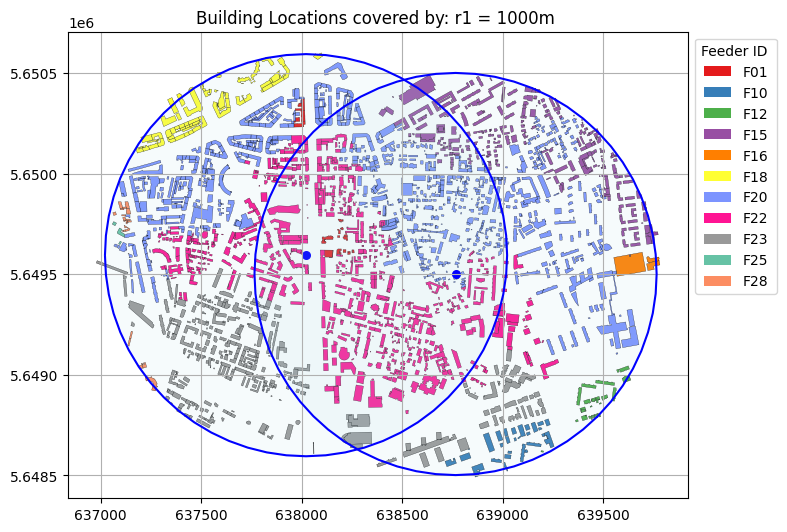

In [21]:
from matplotlib.patches import Patch
bd_in_circle["HTA_maille"] = bd_in_circle["HTA_maille"].astype(str).str.strip()
colors_32 = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#ffff33", "#a65628", "#f781bf",
    "#999999", "#66c2a5", "#fc8d62", "#8da0cb",
    "#e78ac3", "#a6d854", "#ffd92f", "#e5c494",
    "#b3b3b3", "#1b9e77", "#d95f02", "#7570b3",
    "#e7298a", "#66a61e", "#e6ab02", "#a6761d",
    "#666666", "#1f78b4", "#33a02c", "#fb9a99",
    "#cab2d6", "#6a3d9a", "#b15928", "#17becf"]

feeders = sorted(bd_in_circle["HTA_maille"].dropna().unique())
color_map = {feeder: colors_32[i % len(colors_32)]
    for i, feeder in enumerate(feeders)}

color_map["F22"] = "#ff1493"
color_map["F20"] = "#002FFF83"
bd_in_circle["color"] = bd_in_circle["HTA_maille"].map(color_map)
bd_in_circle["color"] = bd_in_circle["color"].fillna("#cccccc")
circle1 = center_point1.buffer(r1)
circle2 = center_point2.buffer(r2)
fig, ax = plt.subplots(figsize=(8, 8))

bd_in_circle.plot(ax=ax,color=bd_in_circle["color"],edgecolor="black",linewidth=0.2)

gpd.GeoSeries([circle1], crs=bd_in_circle.crs).plot(ax=ax,facecolor="lightblue",alpha=0.1)
gpd.GeoSeries([circle1], crs=bd_in_circle.crs).boundary.plot(ax=ax,color="blue",linewidth=1.5)
gpd.GeoSeries([center_point1], crs=bd_in_circle.crs).plot(ax=ax,marker="o",color="blue",markersize=30)

gpd.GeoSeries([circle2], crs=bd_in_circle.crs).plot(ax=ax,facecolor="lightblue",alpha=0.1)
gpd.GeoSeries([circle2], crs=bd_in_circle.crs).boundary.plot(ax=ax,color="blue",linewidth=1.5)
gpd.GeoSeries([center_point2], crs=bd_in_circle.crs).plot(ax=ax,marker="o",color="blue",markersize=30)

handles = [Patch(facecolor=color_map[f], label=f)for f in feeders]

ax.legend(handles=handles,title="Feeder ID ",loc="upper left",bbox_to_anchor=(1, 1))
ax.set_aspect("equal")
ax.grid(True)
ax.set_title(f"Building Locations covered by: r1 = {r1}m ")

plt.show()

In [22]:
bd_type1 = bd_in_circle.groupby(['HTA_maille', 'FUS_usage_principal']).size().unstack(fill_value=0)
bd_type1['total'] = bd_type1.sum(axis=1)
items5 = ['Résidentiel collectif', 'Résidentiel individuel', 'Tertiaire', 'Dépendance', 'Secondaire', 'Tertiaire & Autres', 'total']
bd_type1 = bd_type1.reindex(columns=items5, fill_value=0)
bd_type1

FUS_usage_principal,Résidentiel collectif,Résidentiel individuel,Tertiaire,Dépendance,Secondaire,Tertiaire & Autres,total
HTA_maille,,,,,,,
F01,19,10,0,0,0,0,29
F10,25,0,4,0,0,0,29
F12,17,4,3,0,0,0,24
F15,119,118,29,0,0,1,267
F16,2,0,1,0,0,0,3
F18,63,2,9,0,0,0,74
F20,516,309,92,1,0,0,918
F22,419,312,108,6,0,0,845
F23,195,82,72,0,0,0,349


### 5. List of number building types associated with feeder pair

In [23]:
bd_type = combined_df.groupby(['pair_label', 'FUS_usage_principal']).size().unstack(fill_value=0)
bd_type['total'] = bd_type.sum(axis=1)
items5 = ['Résidentiel collectif', 'Résidentiel individuel', 'Tertiaire', 'Dépendance', 'Secondaire', 'Tertiaire & Autres', 'total']
bd_type = bd_type.reindex(columns=items5, fill_value=0)
bd_type

FUS_usage_principal,Résidentiel collectif,Résidentiel individuel,Tertiaire,Dépendance,Secondaire,Tertiaire & Autres,total
pair_label,,,,,,,
F07_F27,695,473,136,5,0,0,1309
F20_F22,935,621,200,7,0,0,1763


#### 5.1. Calculation the building ratios associate with the feeder pair

In [24]:
bd_ratio = pd.DataFrame({
    'Résidentiel collectif_ratio': bd_type.get('Résidentiel collectif', 0) / bd_type['total'],
    'Résidentiel individuel_ratio': bd_type.get('Résidentiel individuel', 0) / bd_type['total'],
    'Tertiaire_ratio': bd_type.get('Tertiaire', 0) / bd_type['total'],
    'Dépendance_ratio': bd_type.get('Dépendance', 0) / bd_type['total'],
    'Secondaire_ratio': bd_type.get('Secondaire', 0) / bd_type['total'],
    'Tertiaire & Autres_ratio': bd_type.get('Tertiaire & Autres', 0) / bd_type['total'],
    'total_residen_ratio': (bd_type.get('Résidentiel collectif', 0) + bd_type.get('Résidentiel individuel', 0)) / bd_type['total']})
bd_ratio

,Résidentiel collectif_ratio,Résidentiel individuel_ratio,Tertiaire_ratio,Dépendance_ratio,Secondaire_ratio,Tertiaire & Autres_ratio,total_residen_ratio
pair_label,,,,,,,
F07_F27,0.530940,0.361345,0.103896,0.003820,0.0,0.0,0.892284
F20_F22,0.530346,0.352240,0.113443,0.003971,0.0,0.0,0.882587


### 6. List of energy share to each building type

In [25]:
conso_type = combined_df.groupby(['pair_label', 'FUS_usage_principal'])['conso_par_persone_mwh'].sum().unstack(fill_value=0)
conso_type = conso_type.reindex(columns=items5, fill_value=0)
conso_type['total'] = conso_type.sum(axis=1)
conso_type

FUS_usage_principal,Résidentiel collectif,Résidentiel individuel,Tertiaire,Dépendance,Secondaire,Tertiaire & Autres,total
pair_label,,,,,,,
F07_F27,1205.719643,882.31239,251.075216,8.574395,0,0,2347.681643
F20_F22,1615.484543,1156.62099,625.245252,12.507242,0,0,3409.858027


#### 6.1. Calculation pecentage of energy share to each building type

In [26]:
conso_pct = pd.DataFrame({
    'Résidentiel collectif_pct': conso_type.get('Résidentiel collectif', 0) / conso_type['total'] * 100,
    'Résidentiel individuel_pct': conso_type.get('Résidentiel individuel', 0) / conso_type['total'] * 100,
    'Tertiaire_pct': conso_type.get('Tertiaire', 0) / conso_type['total'] * 100,
    'Dépendance_pct': conso_type.get('Dépendance', 0) / conso_type['total'] * 100,
    'Secondaire_pct': conso_type.get('Secondaire', 0) / conso_type['total'] * 100,
    'Tertiaire & Autres_pct': conso_type.get('Tertiaire & Autres', 0) / conso_type['total'] * 100,
    'total_residen_pct': (conso_type.get('Résidentiel collectif', 0) + conso_type.get('Résidentiel individuel', 0)) / conso_type['total'] * 100})
conso_pct

,Résidentiel collectif_pct,Résidentiel individuel_pct,Tertiaire_pct,Dépendance_pct,Secondaire_pct,Tertiaire & Autres_pct,total_residen_pct
pair_label,,,,,,,
F07_F27,51.357885,37.582284,10.694602,0.365228,0.0,0.0,88.940169
F20_F22,47.376886,33.919916,18.336401,0.366797,0.0,0.0,81.296802


### 7. Check the distribution plot of socio-economic features

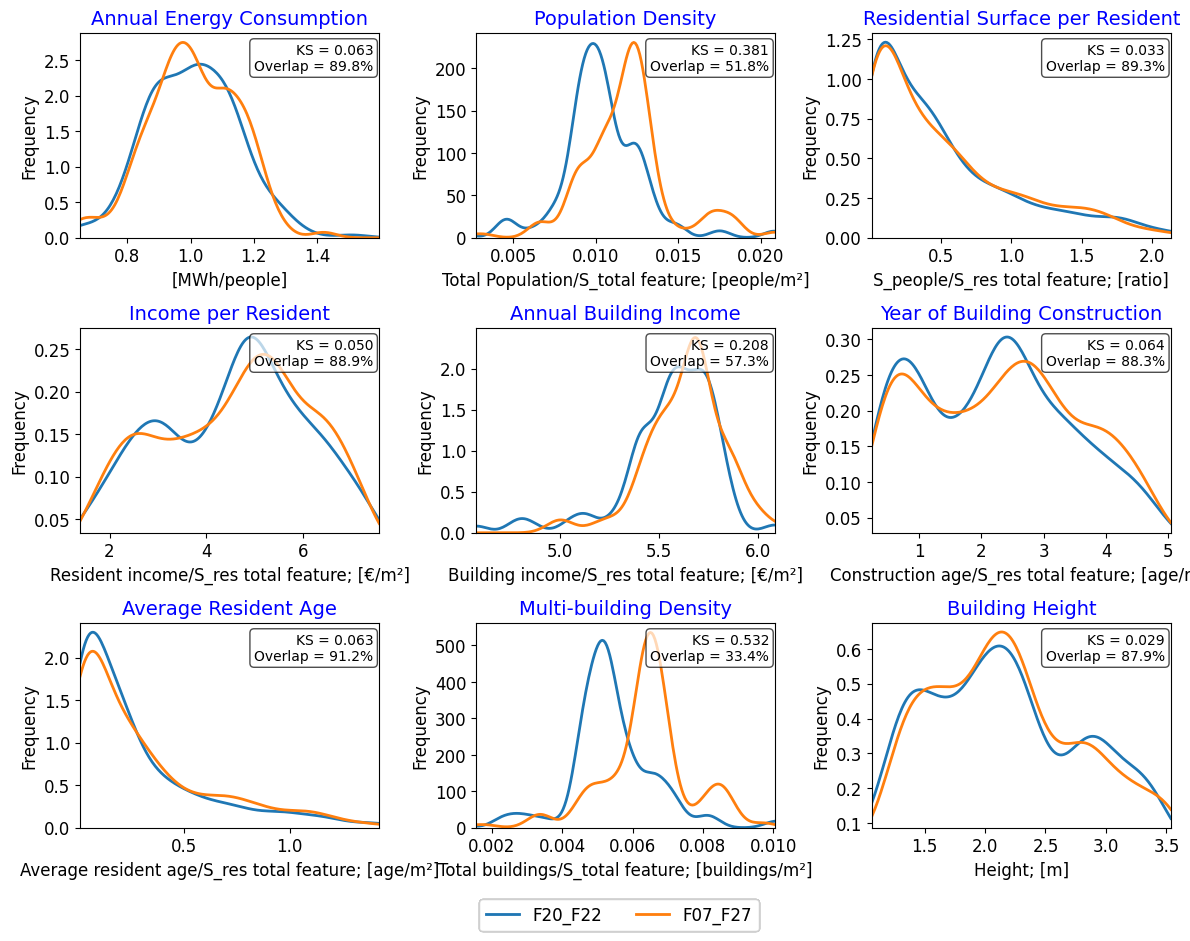

In [27]:
from scipy.stats import ks_2samp

features = ['conso_par_persone_mwh','CARREAU_nb_individus','CARREAU_surface_par_personne','CARREAU_revenu_par_habitant','CARREAU_revenu_bat','FUS_annee_construction','CARREAU_age_moyen_occupants','CARREAU_nb_menages', 'BDNB_hauteur']

title_map = {
    'conso_par_persone_mwh': "Annual Energy Consumption",
    'CARREAU_nb_individus': "Population Density",
    'CARREAU_surface_par_personne': "Residential Surface per Resident",
    'CARREAU_revenu_par_habitant': "Income per Resident",
    'CARREAU_revenu_bat': "Annual Building Income",
    'FUS_annee_construction': "Year of Building Construction",
    'CARREAU_age_moyen_occupants': "Average Resident Age",
    'CARREAU_nb_menages': "Multi-building Density",
    'BDNB_hauteur': "Building Height"}

xlabel_map = {
    'conso_par_persone_mwh': "[MWh/people]",
    'CARREAU_nb_individus':"Total Population/S_total feature; [people/m²]",
    'CARREAU_surface_par_personne':"S_people/S_res total feature; [ratio]",
    'CARREAU_revenu_par_habitant':"Resident income/S_res total feature; [€/m²]",
    'CARREAU_revenu_bat':"Building income/S_res total feature; [€/m²]",
    'FUS_annee_construction':"Construction age/S_res total feature; [age/m²]",
    'CARREAU_age_moyen_occupants':"Average resident age/S_res total feature; [age/m²]",
    'CARREAU_nb_menages':"Total buildings/S_total feature; [buildings/m²]",
    'BDNB_hauteur':"Height; [m]"}

df1 = combined_df[combined_df['pair_label'] == col1[0]]
df2 = combined_df[combined_df['pair_label'] == col1[1]]

n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
axes = axes.flatten()
for i, feature in enumerate(features):
    ax = axes[i]
    # Skip missing columns
    if feature not in combined_df.columns:
        continue
    # Extract data
    x = df1[feature].values
    y = df2[feature].values
    # Remove NaN, inf, and zeros
    x = x[np.isfinite(x) & (x > 0)]
    y = y[np.isfinite(y) & (y > 0)]

    if len(x) == 0 or len(y) == 0:
        continue
    # Optional LOG TRANSFORM (recommended for skewed data)
    use_log = True
    if use_log:
        x_plot = np.log1p(x)
        y_plot = np.log1p(y)
        xlabel = f" {xlabel_map.get(feature, feature)}"
    else:
        x_plot = x
        y_plot = y
        xlabel = xlabel_map.get(feature, feature)
    stat, p_value = ks_2samp(x_plot, y_plot)
    hist1, bins = np.histogram(x_plot, bins=50, density=True)
    hist2, _ = np.histogram(y_plot, bins=bins, density=True)

    bin_width = bins[1] - bins[0]
    overlap = np.sum(np.minimum(hist1, hist2)) * bin_width
    all_data = np.concatenate([x_plot, y_plot])
    xmin = np.percentile(all_data, 1)
    xmax = np.percentile(all_data, 99)

    sns.kdeplot(x=x_plot,ax=ax,label=col1[0],clip=(xmin, xmax),linewidth=2)
    sns.kdeplot(x=y_plot,ax=ax,label=col1[1],clip=(xmin, xmax),linewidth=2)

    # APPLY ZOOM
    ax.set_xlim(xmin, xmax)
    # ax.set_title(feature, fontsize=11)
    ax.set_title(title_map.get(feature, feature),fontsize=14, color ='blue')
    ax.set_xlabel(xlabel_map.get(feature, feature),fontsize=12)
    ax.set_ylabel("Frequency", fontsize = 12)
    ax.tick_params(axis='both', labelsize= 12)
    textstr = (f"KS = {stat:.3f}\n"
        f"Overlap = {overlap*100:.1f}%")

    ax.text(0.98,0.95,textstr,transform=ax.transAxes,fontsize=10,va='top',ha='right',bbox=dict(boxstyle="round",facecolor="white",alpha=0.7))

    # reference line
    ax.axvline(np.log1p(0) if use_log else 0,color='black',linestyle='--',linewidth=1)
    # ax.legend() #show all the legend
    # Get handles and labels from the first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(0.52, -0.05),ncol=2,fontsize=12,frameon=True)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()